# Ablation comparison

Compares bias-corrected precipitation across **ablation experiments** (rather than against
external benchmark methods, which is what `analysis_ensemble.ipynb` does).

Each experiment = one output tree (`outputs/<exp>/jobs_LOCAspatioTempConv1d/`) containing one
trained run per CMIP6 GCM. For every experiment we load the evaluated test output (`xt.pt`) for
each GCM and compare against the shared raw model (`x`) and reference observations (`y`).

Outputs (in `plot_results/ablation/`):
1. Median |bias| (%) of the nine ETCCDI precipitation indices over the held-out period
   2001–2014 — pooled across GCMs and multi-model mean (MM)
2. Fractal dimension of the spatial structure (temporal test)
3. Median |bias| (%) of the same indices in the held-out region (HUC-02 region 05, Ohio) —
   pooled and MM


In [1]:
import sys
import os

from pathlib import Path

# Walk up from the current directory until we hit the repo root (marked by run_exp.py)
ROOT = Path.cwd().resolve()
while not (ROOT / 'run_exp.py').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / 'run_exp.py').exists():
    raise RuntimeError("Could not locate dCLIMBA-release repo root")
sys.path.insert(0, str(ROOT))

import glob
import yaml
import numpy as np
import pandas as pd
import torch
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

from eval.metrics import *
from eval.plot import *
import data.valid_crd as valid_crd
import data.helper as helper

/pscratch/sd/k/kas7897/.conda/envs/dCLIMAD/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. CONFIG — edit this cell

In [2]:
REPO_ROOT    = str(ROOT)
OUTPUTS_ROOT = os.path.join(REPO_ROOT, 'outputs')
JOBS_SUBDIR  = 'jobs_LOCAspatioTempConv1d'   # temporal encoder used for these runs

# Some runs saved `cmip_dir` as a relative path (resolved from the repo root), others
# as absolute. Set this to force one location for every experiment; None = use each
# run's own train_config.yaml value, resolving relative paths against REPO_ROOT.
CMIP_DIR_OVERRIDE = None

TEST_PERIOD = [2001, 2014]

# GCM order. `exps` / `testep` below must follow this same order.
GCMS = ['access_cm2', 'gfdl_esm4', 'ipsl_cm6a_lr', 'miroc6', 'mpi_esm1_2_lr', 'mri_esm2_0']
GCM_LABELS = ['ACCESS-CM2', 'GFDL-ESM4', 'IPSL-CM6A-LR', 'MIROC6', 'MPI-ESM1-2-LR', 'MRI-ESM2-0']

# GCM whose grid is used as the common grid when pooling across GCMs.
REF_GCM_INDEX = 2

# ---------------------------------------------------------------------------
# One entry per experiment.
#   exps   : run_id per GCM, in GCMS order. Use None to skip a GCM.
#   testep : evaluated epoch per GCM, in GCMS order. Use None to skip a GCM.
# ---------------------------------------------------------------------------
EXPERIMENTS = {
    'Baseline (full)': dict(
        exp_dir = 'Final_repeat_nowghtdecay_5b',
        exps    = ['5fcf8609', '5fe5fe59', '835d522f', '38765d44', 'f6118645', '045f73d3'],
        testep  = [10,10,30,20,30,10],
    ),
    'No spatial attn': dict(
        exp_dir = 'Final_repeat_nowghtdecay_5b_noattn',
        exps    = ['aed77ac6', 'd5cb91f6', '92af2c2c', '8b22396a', 'ed7dbc90', 'be3da74a'],
        testep  = [10,20,10,50,10,10],
    ),
    'No attributes': dict(
        exp_dir = 'Final_repeat_nowghtdecay_5b_no_attri',
        exps    = ['dfb00707', 'fe4476cf', '9faec7d2', 'c6e1f11b', '6710915d', '0810bdf3'],
        testep  = [10,10,10,10,70,10],
    ),
   
    # e.g. the transform_type=direct run:
    'Direct output': dict(
        exp_dir = 'Final_repeat_nowghtdecay_direct',
        exps    = ['40f59b61', '063b261b', '962d525f', '5fd5495e', 'e8979acd', '289f359a'],
        testep  = [20,20,40,20,70,10],
    ),
}

SAVE_DIR = os.path.join(REPO_ROOT, 'plot_results', 'ablation')
os.makedirs(SAVE_DIR, exist_ok=True)


def base_dir_of(spec):
    return os.path.join(OUTPUTS_ROOT, spec['exp_dir'], JOBS_SUBDIR)


print(f'{len(EXPERIMENTS)} experiments configured; results -> {SAVE_DIR}')

4 experiments configured; results -> /pscratch/sd/k/kas7897/dCLIMBA-release/plot_results/ablation


## 2. Load data

`x` (raw GCM), `y` (reference obs) and `xt` (bias-corrected) per experiment x GCM.
`y` is filtered onto the GCM calendar, exactly as in `analysis_ensemble.ipynb`.

In [3]:
def load_model_run(run_id, epoch, base_dir, test_period=TEST_PERIOD):
    run_path = helper.load_run_path(run_id, base_dir)
    data_path = os.path.join(run_path, f'{test_period[0]}_{test_period[1]}')

    x = torch.load(os.path.join(data_path, 'x.pt'), map_location='cpu',
                   weights_only=True).squeeze(-1).numpy()
    x[x < 0.254] = 0
    y = torch.load(os.path.join(data_path, 'y.pt'), map_location='cpu',
                   weights_only=True).squeeze(-1).numpy()
    y[y < 0.254] = 0
    time = torch.load(os.path.join(data_path, 'time.pt'), map_location='cpu', weights_only=False)

    xt_path = os.path.join(data_path, f'ep{epoch}', 'xt.pt')
    xt = torch.load(xt_path, map_location='cpu', weights_only=False)
    xt = np.asarray(xt)
    xt[xt < 0.254] = 0

    with open(os.path.join(run_path, 'train_config.yaml'), 'r') as f:
        config = yaml.safe_load(f)

    # Align y onto the GCM calendar (CMIP6 calendars drop days, e.g. noleap)
    x_time_np = np.array([pd.Timestamp(str(t)) for t in time])
    x_time_np = np.array([pd.Timestamp(t).replace(hour=0, minute=0, second=0) for t in x_time_np],
                         dtype='datetime64[D]')
    y_time_np = pd.date_range(start=f'{test_period[0]}-01-01',
                              end=f'{test_period[1]}-12-31', freq='D').to_numpy()
    matched = np.where(np.isin(y_time_np, x_time_np))[0]
    y = y[matched, :]

    return dict(run_path=run_path, run_id=run_id, epoch=epoch, x=x, y=y, xt=xt,
                time=time, x_time_np=x_time_np, config=config)


def resolve_cmip_dir(config):
    """Handles configs that stored cmip_dir relative to the repo root vs. absolute."""
    if CMIP_DIR_OVERRIDE:
        return CMIP_DIR_OVERRIDE
    cmip_dir = config['cmip_dir']
    if not os.path.isabs(cmip_dir):
        cmip_dir = os.path.join(REPO_ROOT, cmip_dir)
    return cmip_dir


def load_valid_coords(config):
    ds_sample = xr.open_dataset(
        f"{resolve_cmip_dir(config)}/{config['clim']}/historical/precipitation/clipped_US.nc")
    shapefile_path = None if not config.get('spatial_test') else config['shapefile_filter_path']
    spatial_extent = config.get('spatial_extent_test', config.get('spatial_extent_val'))
    return valid_crd.valid_lat_lon(ds_sample, var_name='pr',
                                   shapefile_path=shapefile_path, attrList=spatial_extent)


DATA = {}     # DATA[exp_name][gcm_index] = run dict (or None if skipped/missing)
COORDS = {}   # COORDS[gcm_index] = valid coords for that GCM grid

for name, spec in EXPERIMENTS.items():
    base_dir = base_dir_of(spec)
    runs = []
    for gi, gcm in enumerate(GCMS):
        run_id = spec['exps'][gi] if gi < len(spec['exps']) else None
        epoch = spec['testep'][gi] if gi < len(spec['testep']) else None
        if run_id is None or epoch is None:
            print(f'[skip] {name:22s} {gcm:16s} (no run_id/epoch given)')
            runs.append(None)
            continue
        try:
            run = load_model_run(run_id, epoch, base_dir)
        except Exception as err:
            print(f'[FAIL] {name:22s} {gcm:16s} {run_id} ep{epoch}: {type(err).__name__}: {err}')
            runs.append(None)
            continue
        runs.append(run)
        if gi not in COORDS:
            COORDS[gi] = load_valid_coords(run['config'])
        print(f'[ok]   {name:22s} {gcm:16s} {run_id} ep{epoch}  '
              f'x{run["x"].shape} y{run["y"].shape} xt{run["xt"].shape}')
    DATA[name] = runs

EXP_NAMES = [n for n in EXPERIMENTS if any(r is not None for r in DATA[n])]

# Every comparison below uses the SAME set of GCMs for every experiment, otherwise an
# experiment missing a GCM would be scored on a different sample than the others.
COMMON_GCM_IDX = [gi for gi in range(len(GCMS))
                  if all(DATA[n][gi] is not None for n in EXP_NAMES)]
dropped = [GCMS[gi] for gi in range(len(GCMS)) if gi not in COMMON_GCM_IDX]

print(f'\nLoaded experiments: {EXP_NAMES}')
print(f'GCMs common to all experiments: {[GCMS[gi] for gi in COMMON_GCM_IDX]}')
if dropped:
    print(f'WARNING: dropped from all comparisons (missing in >=1 experiment): {dropped}')
if not COMMON_GCM_IDX:
    raise RuntimeError('No GCM is available across all experiments - fill in more runs.')
if REF_GCM_INDEX not in COMMON_GCM_IDX:
    REF_GCM_INDEX = COMMON_GCM_IDX[0]
    print(f'REF_GCM_INDEX not in common set; using {GCMS[REF_GCM_INDEX]} as the common grid.')

[ok]   Baseline (full)        access_cm2       5fcf8609 ep10  x(5113, 346) y(5113, 346) xt(5113, 346)
[ok]   Baseline (full)        gfdl_esm4        5fe5fe59 ep10  x(5110, 658) y(5110, 658) xt(5110, 658)
[ok]   Baseline (full)        ipsl_cm6a_lr     835d522f ep30  x(5113, 252) y(5113, 252) xt(5113, 252)
[ok]   Baseline (full)        miroc6           38765d44 ep20  x(5113, 416) y(5113, 416) xt(5113, 416)
[ok]   Baseline (full)        mpi_esm1_2_lr    f6118645 ep30  x(5113, 230) y(5113, 230) xt(5113, 230)
[ok]   Baseline (full)        mri_esm2_0       045f73d3 ep10  x(5113, 659) y(5113, 659) xt(5113, 659)
[ok]   No spatial attn        access_cm2       aed77ac6 ep10  x(5113, 346) y(5113, 346) xt(5113, 346)
[ok]   No spatial attn        gfdl_esm4        d5cb91f6 ep20  x(5110, 658) y(5110, 658) xt(5110, 658)
[ok]   No spatial attn        ipsl_cm6a_lr     92af2c2c ep10  x(5113, 252) y(5113, 252) xt(5113, 252)
[ok]   No spatial attn        miroc6           8b22396a ep50  x(5113, 416) y(5113,

## 3. ETCCDI precipitation-index bias

Indices are computed per GCM, mapped onto the reference GCM grid, then pooled across GCMs
(same pooling as `analysis_ensemble.ipynb`). Bias is % relative to the reference.

In [4]:
def find_nearest_indices(query_coords, target_coords):
    """For each row in query_coords, index of nearest row in target_coords."""
    nearest_indices, nearest_coords = [], []
    for coord in query_coords:
        dists = np.linalg.norm(target_coords - coord, axis=1)
        idx = int(np.argmin(dists))
        nearest_indices.append(idx)
        nearest_coords.append(target_coords[idx])
    return nearest_indices, np.array(nearest_coords)

In [5]:
climate_indices = ClimateIndices()
thresholds = climate_indices.get_indices()

ensemble_coords = COORDS[REF_GCM_INDEX]
interp_coords = {gi: find_nearest_indices(ensemble_coords, COORDS[gi])[0] for gi in COORDS}

# Pool raw / reference / per-experiment corrected indices across GCMs
x_pool, y_pool = {}, {}
xt_pool = {name: {} for name in EXP_NAMES}

for gi in COMMON_GCM_IDX:
    base_run = next(DATA[n][gi] for n in EXP_NAMES if DATA[n][gi] is not None)
    tgt = interp_coords[gi]
    for label, (threshold, comparison) in thresholds.items():
        if not callable(threshold):
            continue
        xi = threshold(base_run['x_time_np'], base_run['x'])[:, tgt]
        yi = threshold(base_run['x_time_np'], base_run['y'])[:, tgt]
        x_pool.setdefault(label, []).append(xi)
        y_pool.setdefault(label, []).append(yi)
        for name in EXP_NAMES:
            run = DATA[name][gi]
            xti = threshold(run['x_time_np'], run['xt'])[:, tgt]
            xt_pool[name].setdefault(label, []).append(xti)
    print(f'  indices done: {GCMS[gi]}')

for label in list(x_pool):
    x_pool[label] = np.concatenate(x_pool[label], axis=1)
    y_pool[label] = np.concatenate(y_pool[label], axis=1)
    for name in EXP_NAMES:
        xt_pool[name][label] = np.concatenate(xt_pool[name][label], axis=1)

# bias_dict[label] = (raw_bias, exp1_bias, exp2_bias, ...)
bias_dict = {}
for label in x_pool:
    raw_bias = None
    per_exp = []
    for name in EXP_NAMES:
        rb, cb = compute_mean_bias_percentage(None, x_pool[label], y_pool[label],
                                              xt_pool[name][label])
        raw_bias = rb if raw_bias is None else raw_bias
        per_exp.append(cb)
    bias_dict[label] = tuple([raw_bias] + per_exp)

# "Average" row across all indices
n_series = len(EXP_NAMES) + 1
bias_dict['Average'] = tuple(
    np.nanmean([b[k] for b in bias_dict.values()], axis=0) for k in range(n_series)
)
print('indices computed:', [k for k in bias_dict])

  indices done: access_cm2
  indices done: gfdl_esm4
  indices done: ipsl_cm6a_lr
  indices done: miroc6
  indices done: mpi_esm1_2_lr
  indices done: mri_esm2_0
indices computed: ['Rx1day', 'Rx5day', 'SDII (Monthly)', 'R10mm', 'R20mm', 'CDD (Yearly)', 'CWD (Yearly)', 'R95pTOT', 'R99pTOT', 'Average']


In [6]:
# Compact scoreboard: median |bias| % per index (lower is better)
keys = ['SDII (Monthly)', 'CDD (Yearly)', 'CWD (Yearly)', 'Rx1day', 'Rx5day',
        'R10mm', 'R20mm', 'R95pTOT', 'R99pTOT', 'Average']
series_names = ['Raw model'] + list(EXP_NAMES)
table = {}
for label in keys:
    if label not in bias_dict:
        continue
    table[label] = {sn: float(np.nanmedian(np.abs(bias_dict[label][k])))
                    for k, sn in enumerate(series_names)}

score_df = pd.DataFrame(table).T
score_df.index.name = 'Index'
print('Median |bias| % (lower is better); best experiment per index in bold-ish order:')
display(score_df.style.format('{:.2f}').background_gradient(axis=1, cmap='RdYlGn_r'))

score_df.to_csv(f'{SAVE_DIR}/ablation_median_abs_bias.csv')
print(f'saved -> {SAVE_DIR}/ablation_median_abs_bias.csv')

Median |bias| % (lower is better); best experiment per index in bold-ish order:


,Raw model,Baseline (full),No spatial attn,No attributes,Direct output
Index,,,,,
SDII (Monthly),22.77,30.45,19.22,25.73,33.46
CDD (Yearly),22.83,16.07,23.45,19.17,20.16
CWD (Yearly),59.05,18.63,25.45,21.09,26.28
Rx1day,75.43,51.14,35.32,50.04,70.07
Rx5day,93.85,43.23,37.42,48.65,56.96
R10mm,32.55,16.58,20.15,23.83,15.45
R20mm,39.02,29.61,36.59,33.92,24.99
R95pTOT,73.60,21.95,23.52,26.97,23.86
R99pTOT,31.79,49.81,53.24,44.55,47.32


saved -> /pscratch/sd/k/kas7897/dCLIMBA-release/plot_results/ablation/ablation_median_abs_bias.csv


### 3b. Multi-model mean (MM)

Instead of pooling the GCMs as extra grid points, each index is **averaged across GCMs**
on the common grid and the bias of that ensemble mean is taken against a single reference
`y` (`REF_GCM_INDEX`), as in `analysis_spatial_old.ipynb`. One value per grid point, so
GCM errors of opposite sign cancel rather than showing up as spread.

In [7]:
# Multi-model-mean bias. Reuses the pooled arrays above: along axis 1 each GCM is one
# len(ensemble_coords)-wide block, in COMMON_GCM_IDX order.
n_gcm = len(COMMON_GCM_IDX)
ref_pos = COMMON_GCM_IDX.index(REF_GCM_INDEX)


def gcm_mean(pooled, n_gcm):
    return np.mean(np.stack(np.split(pooled, n_gcm, axis=1)), axis=0)


x_mm, y_mm = {}, {}
xt_mm = {name: {} for name in EXP_NAMES}
for label in x_pool:
    x_mm[label] = gcm_mean(x_pool[label], n_gcm)
    y_mm[label] = np.split(y_pool[label], n_gcm, axis=1)[ref_pos]
    for name in EXP_NAMES:
        xt_mm[name][label] = gcm_mean(xt_pool[name][label], n_gcm)

# bias_dict_mm[label] = (raw_bias, exp1_bias, exp2_bias, ...)
bias_dict_mm = {}
for label in x_mm:
    raw_bias = None
    per_exp = []
    for name in EXP_NAMES:
        rb, cb = compute_mean_bias_percentage(None, x_mm[label], y_mm[label], xt_mm[name][label])
        raw_bias = rb if raw_bias is None else raw_bias
        per_exp.append(cb)
    bias_dict_mm[label] = tuple([raw_bias] + per_exp)

bias_dict_mm['Average'] = tuple(
    np.nanmean([b[k] for b in bias_dict_mm.values()], axis=0) for k in range(len(EXP_NAMES) + 1)
)
print(f'MM indices computed over {[GCMS[gi] for gi in COMMON_GCM_IDX]}; '
      f'reference y from {GCMS[REF_GCM_INDEX]}')

MM indices computed over ['access_cm2', 'gfdl_esm4', 'ipsl_cm6a_lr', 'miroc6', 'mpi_esm1_2_lr', 'mri_esm2_0']; reference y from ipsl_cm6a_lr


In [8]:
# Multi-model-mean scoreboard: median |bias| % per index (lower is better)
series_names_mm = ['Raw model'] + list(EXP_NAMES)
table_mm = {}
for label in keys:
    if label not in bias_dict_mm:
        continue
    table_mm[label] = {sn: float(np.nanmedian(np.abs(bias_dict_mm[label][k])))
                       for k, sn in enumerate(series_names_mm)}

score_df_mm = pd.DataFrame(table_mm).T
score_df_mm.index.name = 'Index'
print('Multi-model mean - median |bias| % (lower is better):')
display(score_df_mm.style.format('{:.2f}').background_gradient(axis=1, cmap='RdYlGn_r'))

score_df_mm.to_csv(f'{SAVE_DIR}/ablation_median_abs_bias_MM.csv')
print(f'saved -> {SAVE_DIR}/ablation_median_abs_bias_MM.csv')

Multi-model mean - median |bias| % (lower is better):


,Raw model,Baseline (full),No spatial attn,No attributes,Direct output
Index,,,,,
SDII (Monthly),25.01,33.20,20.09,27.51,34.39
CDD (Yearly),15.76,14.96,24.48,15.97,18.13
CWD (Yearly),70.07,15.16,27.50,23.33,24.39
Rx1day,73.84,55.61,37.61,50.70,73.80
Rx5day,98.48,43.65,40.00,50.62,59.85
R10mm,30.38,12.87,14.06,18.10,11.61
R20mm,40.72,24.72,31.29,27.26,21.77
R95pTOT,71.08,17.54,16.91,24.13,20.71
R99pTOT,22.54,46.82,51.04,41.50,46.44


saved -> /pscratch/sd/k/kas7897/dCLIMBA-release/plot_results/ablation/ablation_median_abs_bias_MM.csv


## 4. Fractal dimension of spatial structure

Box-counting fractal dimension of the time-mean field, per experiment (GCM ensemble mean),
compared against the reference. Lower `|difference|` = spatial structure closer to observations.

`FRACTAL_QUANTILES` is much coarser than in `analysis_ensemble.ipynb` (which used 10,000 points)
— increase it if you need a smoother curve, at a roughly linear cost in runtime.

In [9]:
FRACTAL_QUANTILES = np.arange(0.0, 1.0, 0.01)


def fractal_dimension(Z, threshold):
    """Box-counting fractal dimension of a 2D field, NaNs treated as 0."""
    assert len(Z.shape) == 2
    Z = np.nan_to_num(Z, nan=0)
    Z_bin = (Z < threshold)
    p = min(Z_bin.shape)
    n = int(np.log(p) / np.log(2))
    sizes = 2 ** np.arange(n, 1, -1)

    def boxcount(Z, k):
        S = np.add.reduceat(
            np.add.reduceat(Z, np.arange(0, Z.shape[0], k), axis=0),
            np.arange(0, Z.shape[1], k), axis=1)
        return len(np.where((S > 0) & (S < k * k))[0])

    counts = [boxcount(Z_bin, size) for size in sizes]
    coeffs = np.polyfit(np.log(sizes), np.log(counts), 1)
    return -coeffs[0]


def mean_field(run, key):
    nc = valid_crd.reconstruct_nc(run[key], COORDS[GCMS.index(run['config']['clim'])],
                                  run['x_time_np'], var='pr')
    return nc['pr'].values.mean(axis=0)


def dim_curve(field):
    return np.array([fractal_dimension(field, np.nanquantile(field, q))
                     for q in FRACTAL_QUANTILES])


dim_ref, dim_raw = [], []
dim_exp = {name: [] for name in EXP_NAMES}

for gi in COMMON_GCM_IDX:
    base_run = next(DATA[n][gi] for n in EXP_NAMES if DATA[n][gi] is not None)
    dim_ref.append(dim_curve(mean_field(base_run, 'y')))
    dim_raw.append(dim_curve(mean_field(base_run, 'x')))
    for name in EXP_NAMES:
        dim_exp[name].append(dim_curve(mean_field(DATA[name][gi], 'xt')))
    print(f'fractal dims done: {GCMS[gi]}')

dim_ref = np.stack(dim_ref).mean(axis=0)
dim_raw = np.stack(dim_raw).mean(axis=0)
dim_exp = {k: np.stack(v).mean(axis=0) for k, v in dim_exp.items() if v}
print('fractal dimension curves ready')

fractal dims done: access_cm2
fractal dims done: gfdl_esm4
fractal dims done: ipsl_cm6a_lr
fractal dims done: miroc6
fractal dims done: mpi_esm1_2_lr
fractal dims done: mri_esm2_0
fractal dimension curves ready


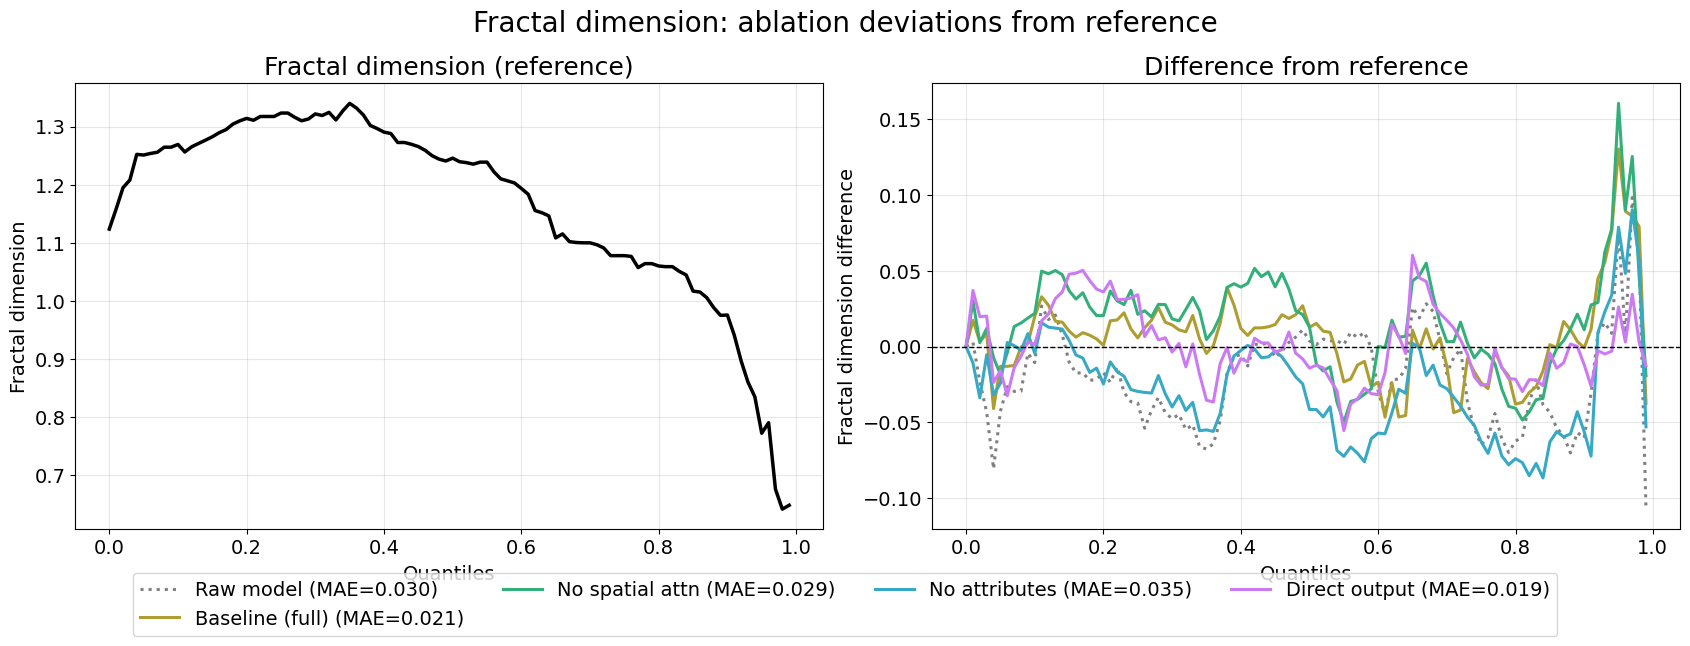

In [10]:
fig, (ax_obs, ax_diff) = plt.subplots(1, 2, figsize=(17, 6))

ax_obs.plot(FRACTAL_QUANTILES, dim_ref, color='black', linewidth=2.5, label='Reference')
ax_obs.set_title('Fractal dimension (reference)', fontsize=18)
ax_obs.set_xlabel('Quantiles', fontsize=14)
ax_obs.set_ylabel('Fractal dimension', fontsize=14)
ax_obs.tick_params(labelsize=14)
ax_obs.grid(True, alpha=0.3)

# Colour-blind-safe styles (eval/plot.py). The full model keeps δCLIMBA's style from
# the other figures; the ablated variants take the generic series styles.
ablation_styles, n_variant = {}, 0
for name in EXP_NAMES:
    if name.startswith('Baseline'):
        ablation_styles[name] = method_style('δCLIMBA')
    else:
        ablation_styles[name] = dict(SERIES_STYLES[n_variant % len(SERIES_STYLES)])
        n_variant += 1

diff_raw = dim_raw - dim_ref
ax_diff.plot(FRACTAL_QUANTILES, diff_raw, **method_style('Raw'), linewidth=2.2,
             markersize=7, markevery=0.08,
             label=f'Raw model (MAE={np.nanmean(np.abs(diff_raw)):.3f})')
for name in EXP_NAMES:
    if name not in dim_exp:
        continue
    diff = dim_exp[name] - dim_ref
    ax_diff.plot(FRACTAL_QUANTILES, diff, **ablation_styles[name], linewidth=2.2,
                 markersize=7, markevery=0.08,
                 label=f'{name} (MAE={np.nanmean(np.abs(diff)):.3f})')

ax_diff.axhline(0, color='black', linestyle='--', linewidth=1)
ax_diff.set_title('Difference from reference', fontsize=18)
ax_diff.set_xlabel('Quantiles', fontsize=14)
ax_diff.set_ylabel('Fractal dimension difference', fontsize=14)
ax_diff.tick_params(labelsize=14)
ax_diff.grid(True, alpha=0.3)

handles, labels = ax_diff.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=min(4, len(labels)),
           bbox_to_anchor=(0.5, -0.08), fontsize=14, frameon=True)
fig.suptitle('Fractal dimension: ablation deviations from reference', fontsize=20)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/ablation_fractalDim.png', bbox_inches='tight', dpi=200)
plt.show()

---
# 5. Spatial (hold-out region) test

The spatial experiments train on most HUC-02 regions, validate on one (`spatial_extent_val`,
region 07 / Upper Mississippi) and test on a region the model never saw
(`spatial_extent_test`, region 05 / Ohio). This section compares the ablations on that
hold-out region, mirroring `analysis_spatial.ipynb`.

This section has its own CONFIG and loader, and does not
depend on the temporal-test results above, but it reuses helpers defined earlier in the
notebook, so run the notebook top-to-bottom.

In [11]:
# ---------------------------------------------------------------------------
# SPATIAL CONFIG - edit this cell
# ---------------------------------------------------------------------------
SPATIAL_EXTENT      = ['05']        # hold-out test region; output dir is str() of this list
SPATIAL_TEST_PERIOD = [1990, 2014]  # spatial runs were trained/tested over 1990-2014
SPATIAL_REF_GCM_INDEX = 2           # GCM whose grid is the common grid when pooling

# exps / testep follow GCMS order (defined in the CONFIG cell at the top).
SPATIAL_EXPERIMENTS = {
    'Baseline (full)': dict(
        exp_dir = 'spatial_Adam_harmonic0',
        exps    = ['4ff90755', 'a3780ca6', '6cde5f80', 'cac5a49c', '627e994f', '4eb36789'] ,
        testep  = [60, 70, 70, 70, 90, 10],
    ),
    'No spatial attn': dict(
        exp_dir = 'spatial_noattn',
        exps    = ['c439f277', 'eceadd9c', 'f97dc9f2', 'e835af7f', '9a65a3d1', '96b4f22a'],
        testep  = [50, 50, 70, 60, 90, 10],
    ),
    'No spatial-corr loss': dict(
        exp_dir = 'spatial_nospatialcorr',
        exps    = ['9fa74cd5', 'fc0ee774', 'e6009ac5', '86e66c2a', 'f6f30c57', 'a8ccad6e'],
        testep  = [20, 80, 90, 100, 50, 100],
    ),
}

SPATIAL_DIR_NAME = f'{SPATIAL_EXTENT}'   # e.g. "['05']"


def spatial_base_dir_of(spec):
    return os.path.join(OUTPUTS_ROOT, spec['exp_dir'], JOBS_SUBDIR)


# --- shared helpers -------------------------------------------------------
# Defined here if the temporal section above was not run, so this section can be
# used on its own (the temporal loader stops early when its `exps` are empty).
if 'find_nearest_indices' not in globals():
    def find_nearest_indices(query_coords, target_coords):
        idx = [int(np.argmin(np.linalg.norm(target_coords - c, axis=1))) for c in query_coords]
        return idx, np.array([target_coords[i] for i in idx])

if 'resolve_cmip_dir' not in globals():
    def resolve_cmip_dir(config):
        cmip_dir = config['cmip_dir']
        return cmip_dir if os.path.isabs(cmip_dir) else os.path.join(REPO_ROOT, cmip_dir)

if 'keys' not in globals():
    keys = ['SDII (Monthly)', 'CDD (Yearly)', 'CWD (Yearly)', 'Rx1day', 'Rx5day',
            'R10mm', 'R20mm', 'R95pTOT', 'R99pTOT', 'Average']


print(f'{len(SPATIAL_EXPERIMENTS)} spatial experiments configured; '
      f'hold-out region dir = {SPATIAL_DIR_NAME}')

3 spatial experiments configured; hold-out region dir = ['05']


In [12]:
def resolve_repo_path(path):
    """Configs store some paths relative to the repo root and some absolute."""
    if path and not os.path.isabs(path):
        return os.path.join(REPO_ROOT, path)
    return path


def load_spatial_run(run_id, epoch, base_dir,
                     extent=SPATIAL_EXTENT, test_period=SPATIAL_TEST_PERIOD):
    run_path = helper.load_run_path(run_id, base_dir)
    data_path = os.path.join(run_path, f'{extent}')

    x = torch.load(os.path.join(data_path, 'x.pt'), map_location='cpu',
                   weights_only=True).squeeze(-1).numpy()
    x[x < 0.254] = 0
    y = torch.load(os.path.join(data_path, 'y.pt'), map_location='cpu',
                   weights_only=True).squeeze(-1).numpy()
    y[y < 0.254] = 0
    time = torch.load(os.path.join(data_path, 'time.pt'), map_location='cpu', weights_only=False)

    xt = np.asarray(torch.load(os.path.join(data_path, f'ep{epoch}', 'xt.pt'),
                               map_location='cpu', weights_only=False))
    xt[xt < 0.254] = 0

    with open(os.path.join(run_path, 'train_config.yaml'), 'r') as f:
        config = yaml.safe_load(f)

    # Align y onto the GCM calendar
    x_time_np = np.array([pd.Timestamp(str(t)) for t in time])
    x_time_np = np.array([pd.Timestamp(t).replace(hour=0, minute=0, second=0) for t in x_time_np],
                         dtype='datetime64[D]')
    y_time_np = pd.date_range(start=f'{test_period[0]}-01-01',
                              end=f'{test_period[1]}-12-31', freq='D').to_numpy()
    matched = np.where(np.isin(y_time_np, x_time_np))[0]
    y = y[matched, :]

    return dict(run_path=run_path, run_id=run_id, epoch=epoch, x=x, y=y, xt=xt,
                time=time, x_time_np=x_time_np, config=config)


def load_spatial_coords(config, extent=SPATIAL_EXTENT):
    """Grid points inside the hold-out region only (HUC-02 shapefile filter)."""
    ds_sample = xr.open_dataset(
        f"{resolve_cmip_dir(config)}/{config['clim']}/historical/precipitation/clipped_US.nc")
    shapefile_path = resolve_repo_path(config['shapefile_filter_path'])
    return valid_crd.valid_lat_lon(ds_sample, var_name='pr', shapefile_path=shapefile_path,
                                   attr='huc2', attrList=extent)


SDATA, SCOORDS = {}, {}
for name, spec in SPATIAL_EXPERIMENTS.items():
    base_dir = spatial_base_dir_of(spec)
    runs = []
    for gi, gcm in enumerate(GCMS):
        run_id = spec['exps'][gi] if gi < len(spec['exps']) else None
        epoch = spec['testep'][gi] if gi < len(spec['testep']) else None
        if run_id is None or epoch is None:
            runs.append(None)
            continue
        try:
            run = load_spatial_run(run_id, epoch, base_dir)
        except Exception as err:
            print(f'[FAIL] {name:22s} {gcm:16s} {run_id} ep{epoch}: {type(err).__name__}: {err}')
            runs.append(None)
            continue
        runs.append(run)
        if gi not in SCOORDS:
            SCOORDS[gi] = load_spatial_coords(run['config'])
        print(f'[ok]   {name:22s} {gcm:16s} {run_id} ep{epoch}  '
              f'x{run["x"].shape} y{run["y"].shape} xt{run["xt"].shape}')
    SDATA[name] = runs

S_EXP_NAMES = [n for n in SPATIAL_EXPERIMENTS if any(r is not None for r in SDATA[n])]
S_COMMON_GCM_IDX = [gi for gi in range(len(GCMS))
                    if S_EXP_NAMES and all(SDATA[n][gi] is not None for n in S_EXP_NAMES)]

print(f'\nSpatial experiments with data: {S_EXP_NAMES}')
missing = [n for n in SPATIAL_EXPERIMENTS if n not in S_EXP_NAMES]
if missing:
    print(f'No hold-out evaluation found for: {missing} (run SPATIAL=true ./auto_eval.sh)')
if S_EXP_NAMES:
    print(f'GCMs common to all: {[GCMS[gi] for gi in S_COMMON_GCM_IDX]}')
    if SPATIAL_REF_GCM_INDEX not in S_COMMON_GCM_IDX and S_COMMON_GCM_IDX:
        SPATIAL_REF_GCM_INDEX = S_COMMON_GCM_IDX[0]
        print(f'SPATIAL_REF_GCM_INDEX -> {GCMS[SPATIAL_REF_GCM_INDEX]}')

[ok]   Baseline (full)        access_cm2       4ff90755 ep60  x(9131, 19) y(9131, 19) xt(9131, 19)
[ok]   Baseline (full)        gfdl_esm4        a3780ca6 ep70  x(9125, 35) y(9125, 35) xt(9125, 35)
[ok]   Baseline (full)        ipsl_cm6a_lr     6cde5f80 ep70  x(9131, 14) y(9131, 14) xt(9131, 14)
[ok]   Baseline (full)        miroc6           cac5a49c ep70  x(9131, 22) y(9131, 22) xt(9131, 22)
[ok]   Baseline (full)        mpi_esm1_2_lr    627e994f ep90  x(9131, 14) y(9131, 14) xt(9131, 14)
[ok]   Baseline (full)        mri_esm2_0       4eb36789 ep10  x(9131, 36) y(9131, 36) xt(9131, 36)
[ok]   No spatial attn        access_cm2       c439f277 ep50  x(9131, 19) y(9131, 19) xt(9131, 19)
[ok]   No spatial attn        gfdl_esm4        eceadd9c ep50  x(9125, 35) y(9125, 35) xt(9125, 35)
[ok]   No spatial attn        ipsl_cm6a_lr     f97dc9f2 ep70  x(9131, 14) y(9131, 14) xt(9131, 14)
[ok]   No spatial attn        miroc6           e835af7f ep60  x(9131, 22) y(9131, 22) xt(9131, 22)
[ok]   No 

In [13]:
# ETCCDI indices on the hold-out region, pooled across GCMs
if not S_COMMON_GCM_IDX:
    raise RuntimeError('No GCM available across all spatial experiments - '
                       'fill in SPATIAL_EXPERIMENTS or run the hold-out evaluation first.')

s_thresholds = ClimateIndices().get_indices()
s_ensemble_coords = SCOORDS[SPATIAL_REF_GCM_INDEX]
s_interp_coords = {gi: find_nearest_indices(s_ensemble_coords, SCOORDS[gi])[0]
                   for gi in SCOORDS}

sx_pool, sy_pool = {}, {}
sxt_pool = {name: {} for name in S_EXP_NAMES}

for gi in S_COMMON_GCM_IDX:
    base_run = next(SDATA[n][gi] for n in S_EXP_NAMES if SDATA[n][gi] is not None)
    tgt = s_interp_coords[gi]
    for label, (threshold, comparison) in s_thresholds.items():
        if not callable(threshold):
            continue
        sx_pool.setdefault(label, []).append(
            threshold(base_run['x_time_np'], base_run['x'])[:, tgt])
        sy_pool.setdefault(label, []).append(
            threshold(base_run['x_time_np'], base_run['y'])[:, tgt])
        for name in S_EXP_NAMES:
            run = SDATA[name][gi]
            sxt_pool[name].setdefault(label, []).append(
                threshold(run['x_time_np'], run['xt'])[:, tgt])
    print(f'  indices done: {GCMS[gi]}')

for label in list(sx_pool):
    sx_pool[label] = np.concatenate(sx_pool[label], axis=1)
    sy_pool[label] = np.concatenate(sy_pool[label], axis=1)
    for name in S_EXP_NAMES:
        sxt_pool[name][label] = np.concatenate(sxt_pool[name][label], axis=1)

s_bias_dict = {}
for label in sx_pool:
    raw_bias, per_exp = None, []
    for name in S_EXP_NAMES:
        rb, cb = compute_mean_bias_percentage(None, sx_pool[label], sy_pool[label],
                                              sxt_pool[name][label])
        raw_bias = rb if raw_bias is None else raw_bias
        per_exp.append(cb)
    s_bias_dict[label] = tuple([raw_bias] + per_exp)

s_bias_dict['Average'] = tuple(
    np.nanmean([b[k] for b in s_bias_dict.values()], axis=0)
    for k in range(len(S_EXP_NAMES) + 1)
)
print('hold-out region indices computed:', list(s_bias_dict))

  indices done: access_cm2
  indices done: gfdl_esm4
  indices done: ipsl_cm6a_lr
  indices done: miroc6
  indices done: mpi_esm1_2_lr
  indices done: mri_esm2_0
hold-out region indices computed: ['Rx1day', 'Rx5day', 'SDII (Monthly)', 'R10mm', 'R20mm', 'CDD (Yearly)', 'CWD (Yearly)', 'R95pTOT', 'R99pTOT', 'Average']


In [14]:
# Hold-out region scoreboard: median |bias| % per index (lower is better)
s_series_names = ['Raw model'] + list(S_EXP_NAMES)
s_table = {}
for label in keys:
    if label not in s_bias_dict:
        continue
    s_table[label] = {sn: float(np.nanmedian(np.abs(s_bias_dict[label][k])))
                      for k, sn in enumerate(s_series_names)}

s_score_df = pd.DataFrame(s_table).T
s_score_df.index.name = 'Index'
print(f'Hold-out region {SPATIAL_EXTENT}: median |bias| % (lower is better)')
display(s_score_df.style.format('{:.2f}').background_gradient(axis=1, cmap='RdYlGn_r'))

s_score_df.to_csv(f'{SAVE_DIR}/ablation_spatial_median_abs_bias.csv')
print(f'saved -> {SAVE_DIR}/ablation_spatial_median_abs_bias.csv')

Hold-out region ['05']: median |bias| % (lower is better)


,Raw model,Baseline (full),No spatial attn,No spatial-corr loss
Index,,,,
SDII (Monthly),9.50,24.47,24.71,24.00
CDD (Yearly),13.57,14.80,16.79,14.85
CWD (Yearly),32.39,27.95,28.93,29.78
Rx1day,42.05,41.51,43.61,31.37
Rx5day,43.25,38.93,43.25,39.30
R10mm,13.18,44.20,40.47,39.75
R20mm,31.39,68.14,62.11,63.19
R95pTOT,61.34,47.88,43.09,45.24
R99pTOT,19.55,47.89,47.47,49.80


saved -> /pscratch/sd/k/kas7897/dCLIMBA-release/plot_results/ablation/ablation_spatial_median_abs_bias.csv


### Hold-out region — multi-model mean (MM)

Same as the section above, but with the indices averaged across GCMs before the bias is
computed against a single reference `y` (`SPATIAL_REF_GCM_INDEX`).

In [15]:
# Multi-model-mean bias on the hold-out region. Each GCM is one
# len(s_ensemble_coords)-wide block of the pooled arrays, in S_COMMON_GCM_IDX order.
s_n_gcm = len(S_COMMON_GCM_IDX)
s_ref_pos = S_COMMON_GCM_IDX.index(SPATIAL_REF_GCM_INDEX)

if 'gcm_mean' not in globals():
    def gcm_mean(pooled, n_gcm):
        return np.mean(np.stack(np.split(pooled, n_gcm, axis=1)), axis=0)

sx_mm, sy_mm = {}, {}
sxt_mm = {name: {} for name in S_EXP_NAMES}
for label in sx_pool:
    sx_mm[label] = gcm_mean(sx_pool[label], s_n_gcm)
    sy_mm[label] = np.split(sy_pool[label], s_n_gcm, axis=1)[s_ref_pos]
    for name in S_EXP_NAMES:
        sxt_mm[name][label] = gcm_mean(sxt_pool[name][label], s_n_gcm)

s_bias_dict_mm = {}
for label in sx_mm:
    raw_bias, per_exp = None, []
    for name in S_EXP_NAMES:
        rb, cb = compute_mean_bias_percentage(None, sx_mm[label], sy_mm[label], sxt_mm[name][label])
        raw_bias = rb if raw_bias is None else raw_bias
        per_exp.append(cb)
    s_bias_dict_mm[label] = tuple([raw_bias] + per_exp)

s_bias_dict_mm['Average'] = tuple(
    np.nanmean([b[k] for b in s_bias_dict_mm.values()], axis=0)
    for k in range(len(S_EXP_NAMES) + 1)
)
print(f'hold-out MM indices computed over {[GCMS[gi] for gi in S_COMMON_GCM_IDX]}; '
      f'reference y from {GCMS[SPATIAL_REF_GCM_INDEX]}')

hold-out MM indices computed over ['access_cm2', 'gfdl_esm4', 'ipsl_cm6a_lr', 'miroc6', 'mpi_esm1_2_lr', 'mri_esm2_0']; reference y from ipsl_cm6a_lr


In [16]:
# Hold-out region, multi-model mean: median |bias| % per index (lower is better)
s_series_names_mm = ['Raw model'] + list(S_EXP_NAMES)
s_table_mm = {}
for label in keys:
    if label not in s_bias_dict_mm:
        continue
    s_table_mm[label] = {sn: float(np.nanmedian(np.abs(s_bias_dict_mm[label][k])))
                         for k, sn in enumerate(s_series_names_mm)}

s_score_df_mm = pd.DataFrame(s_table_mm).T
s_score_df_mm.index.name = 'Index'
print(f'Hold-out region {SPATIAL_EXTENT}, multi-model mean - median |bias| % (lower is better):')
display(s_score_df_mm.style.format('{:.2f}').background_gradient(axis=1, cmap='RdYlGn_r'))

s_score_df_mm.to_csv(f'{SAVE_DIR}/ablation_spatial_median_abs_bias_MM.csv')
print(f'saved -> {SAVE_DIR}/ablation_spatial_median_abs_bias_MM.csv')

Hold-out region ['05'], multi-model mean - median |bias| % (lower is better):


,Raw model,Baseline (full),No spatial attn,No spatial-corr loss
Index,,,,
SDII (Monthly),14.04,19.74,33.71,21.47
CDD (Yearly),8.92,10.35,12.94,11.84
CWD (Yearly),33.42,33.05,34.46,24.89
Rx1day,48.11,45.14,55.76,30.91
Rx5day,42.30,28.87,34.34,30.26
R10mm,14.48,23.48,39.53,23.15
R20mm,33.83,56.10,67.73,48.70
R95pTOT,67.74,45.18,57.24,41.08
R99pTOT,23.32,34.18,32.77,29.59


saved -> /pscratch/sd/k/kas7897/dCLIMBA-release/plot_results/ablation/ablation_spatial_median_abs_bias_MM.csv
